In [4]:
# Import required libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

print("Libraries imported successfully!")

Libraries imported successfully!


In [2]:
# Load the dataset

file_path = "../Dataset/Telco_Customer_Churn.csv"

df = pd.read_csv(file_path)

print("Dataset loaded successfully!")

Dataset loaded successfully!


In [3]:
# Display basic information about the dataset

print("Number of rows:", df.shape[0])
print("Number of columns:", df.shape[1])

print("\nColumn names:")
print(df.columns.tolist())

Number of rows: 7043
Number of columns: 21

Column names:
['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn']


In [4]:
# Display the first 10 rows

df.head(10)

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes
5,9305-CDSKC,Female,0,No,No,8,Yes,Yes,Fiber optic,No,...,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,99.65,820.5,Yes
6,1452-KIOVK,Male,0,No,Yes,22,Yes,Yes,Fiber optic,No,...,No,No,Yes,No,Month-to-month,Yes,Credit card (automatic),89.10,1949.4,No
7,6713-OKOMC,Female,0,No,No,10,No,No phone service,DSL,Yes,...,No,No,No,No,Month-to-month,No,Mailed check,29.75,301.9,No
8,7892-POOKP,Female,0,Yes,No,28,Yes,Yes,Fiber optic,No,...,Yes,Yes,Yes,Yes,Month-to-month,Yes,Electronic check,104.80,3046.05,Yes
9,6388-TABGU,Male,0,No,Yes,62,Yes,No,DSL,Yes,...,No,No,No,No,One year,No,Bank transfer (automatic),56.15,3487.95,No


In [5]:
# Check the data types of all columns

df.dtypes

customerID              str
gender                  str
SeniorCitizen         int64
Partner                 str
Dependents              str
tenure                int64
PhoneService            str
MultipleLines           str
InternetService         str
OnlineSecurity          str
OnlineBackup            str
DeviceProtection        str
TechSupport             str
StreamingTV             str
StreamingMovies         str
Contract                str
PaperlessBilling        str
PaymentMethod           str
MonthlyCharges      float64
TotalCharges            str
Churn                   str
dtype: object

In [6]:
# Check for missing values

missing_values = df.isnull().sum()

print(missing_values)

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64


In [7]:
# Check for duplicate rows

duplicate_count = df.duplicated().sum()

print("Number of duplicate rows:", duplicate_count)


# Check for blank/empty values in each column

blank_values = (df == "").sum()

print("\nBlank values in each column:")
print(blank_values)

Number of duplicate rows: 0

Blank values in each column:
customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64


In [8]:
# Convert TotalCharges from text to numeric

df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")

print("TotalCharges converted to numeric.")
print("Missing values after conversion:", df["TotalCharges"].isnull().sum())

TotalCharges converted to numeric.
Missing values after conversion: 11


In [9]:
# Inspect customers with missing TotalCharges

missing_totalcharges = df[df["TotalCharges"].isnull()]

print("Number of customers with missing TotalCharges:", len(missing_totalcharges))

missing_totalcharges[["customerID", "tenure", "MonthlyCharges", "TotalCharges", "Churn"]]

Number of customers with missing TotalCharges: 11


,customerID,tenure,MonthlyCharges,TotalCharges,Churn
488,4472-LVYGI,0,52.55,NaN,No
753,3115-CZMZD,0,20.25,NaN,No
936,5709-LVOEQ,0,80.85,NaN,No
1082,4367-NUYAO,0,25.75,NaN,No
1340,1371-DWPAZ,0,56.05,NaN,No
3331,7644-OMVMY,0,19.85,NaN,No
3826,3213-VVOLG,0,25.35,NaN,No
4380,2520-SGTTA,0,20.00,NaN,No
5218,2923-ARZLG,0,19.70,NaN,No
6670,4075-WKNIU,0,73.35,NaN,No


In [10]:
# Fill missing TotalCharges for customers with zero tenure

df.loc[df["TotalCharges"].isnull(), "TotalCharges"] = 0

print("Missing TotalCharges after cleaning:", df["TotalCharges"].isnull().sum())

Missing TotalCharges after cleaning: 0


In [11]:
# Verify the data types after cleaning

print(df.dtypes)

customerID              str
gender                  str
SeniorCitizen         int64
Partner                 str
Dependents              str
tenure                int64
PhoneService            str
MultipleLines           str
InternetService         str
OnlineSecurity          str
OnlineBackup            str
DeviceProtection        str
TechSupport             str
StreamingTV             str
StreamingMovies         str
Contract                str
PaperlessBilling        str
PaymentMethod           str
MonthlyCharges      float64
TotalCharges        float64
Churn                   str
dtype: object


In [12]:
# Descriptive statistics for numerical columns

df.describe()

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges
count,7043.000000,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692,2279.734304
std,0.368612,24.559481,30.090047,2266.794470
min,0.000000,0.000000,18.250000,0.000000
25%,0.000000,9.000000,35.500000,398.550000
50%,0.000000,29.000000,70.350000,1394.550000
75%,0.000000,55.000000,89.850000,3786.600000
max,1.000000,72.000000,118.750000,8684.800000


In [14]:
# Analyze customer churn

churn_counts = df["Churn"].value_counts()

print("Customer Churn Distribution:")
print(churn_counts)

print("\nChurn Percentage:")
print(df["Churn"].value_counts(normalize=True) * 100)

Customer Churn Distribution:
Churn
No     5174
Yes    1869
Name: count, dtype: int64

Churn Percentage:
Churn
No     73.463013
Yes    26.536987
Name: proportion, dtype: float64


In [15]:
# Calculate overall churn rate

churn_rate = (df["Churn"] == "Yes").mean() * 100

print(f"Overall Churn Rate: {churn_rate:.2f}%")

Overall Churn Rate: 26.54%


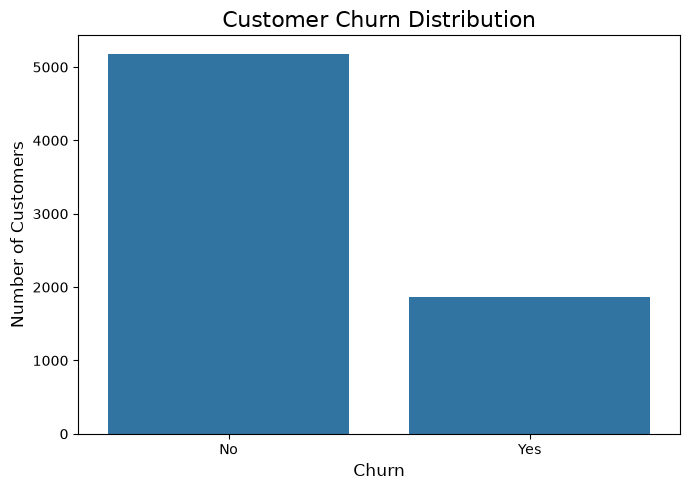

In [16]:
# Visualize customer churn distribution

plt.figure(figsize=(7, 5))

sns.countplot(data=df, x="Churn")

plt.title("Customer Churn Distribution", fontsize=16)
plt.xlabel("Churn", fontsize=12)
plt.ylabel("Number of Customers", fontsize=12)

plt.tight_layout()
plt.show()

In [17]:
# Analyze churn by gender

gender_churn = pd.crosstab(df["gender"], df["Churn"])

print("Churn by Gender:")
print(gender_churn)

Churn by Gender:
Churn     No  Yes
gender           
Female  2549  939
Male    2625  930


In [18]:
# Calculate churn rate by gender

gender_churn_rate = pd.crosstab(
    df["gender"],
    df["Churn"],
    normalize="index"
) * 100

print("Churn Rate by Gender (%):")
print(gender_churn_rate)

Churn Rate by Gender (%):
Churn          No        Yes
gender                      
Female  73.079128  26.920872
Male    73.839662  26.160338


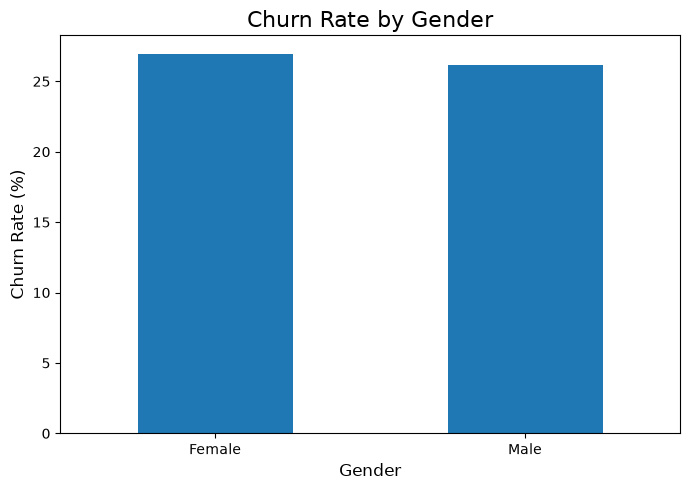

In [19]:
# Visualize churn rate by gender

gender_churn_rate["Yes"].plot(
    kind="bar",
    figsize=(7, 5)
)

plt.title("Churn Rate by Gender", fontsize=16)
plt.xlabel("Gender", fontsize=12)
plt.ylabel("Churn Rate (%)", fontsize=12)
plt.xticks(rotation=0)

plt.tight_layout()
plt.show()

In [20]:
# Calculate churn rate by senior citizen status

senior_churn_rate = pd.crosstab(
    df["SeniorCitizen"],
    df["Churn"],
    normalize="index"
) * 100

print("Churn Rate by Senior Citizen Status (%):")
print(senior_churn_rate)

Churn Rate by Senior Citizen Status (%):
Churn                 No        Yes
SeniorCitizen                      
0              76.393832  23.606168
1              58.318739  41.681261


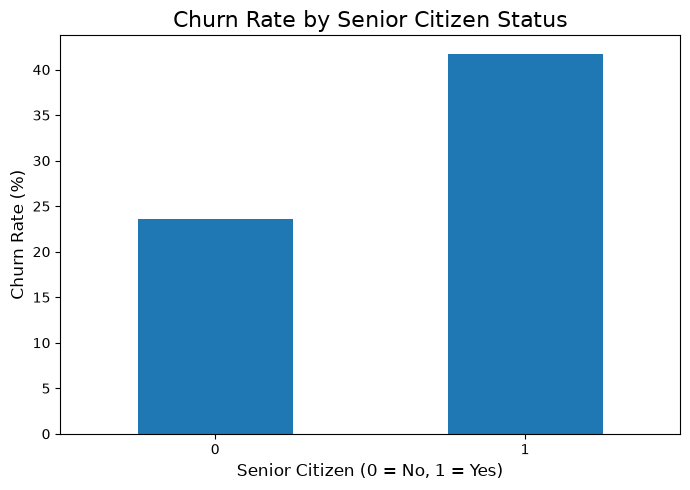

In [21]:
# Visualize churn rate by senior citizen status

senior_churn_rate["Yes"].plot(
    kind="bar",
    figsize=(7, 5)
)

plt.title("Churn Rate by Senior Citizen Status", fontsize=16)
plt.xlabel("Senior Citizen (0 = No, 1 = Yes)", fontsize=12)
plt.ylabel("Churn Rate (%)", fontsize=12)
plt.xticks(rotation=0)

plt.tight_layout()
plt.show()

In [22]:
# Calculate churn rate by contract type

contract_churn_rate = pd.crosstab(
    df["Contract"],
    df["Churn"],
    normalize="index"
) * 100

print("Churn Rate by Contract Type (%):")
print(contract_churn_rate)

Churn Rate by Contract Type (%):
Churn                  No        Yes
Contract                            
Month-to-month  57.290323  42.709677
One year        88.730482  11.269518
Two year        97.168142   2.831858


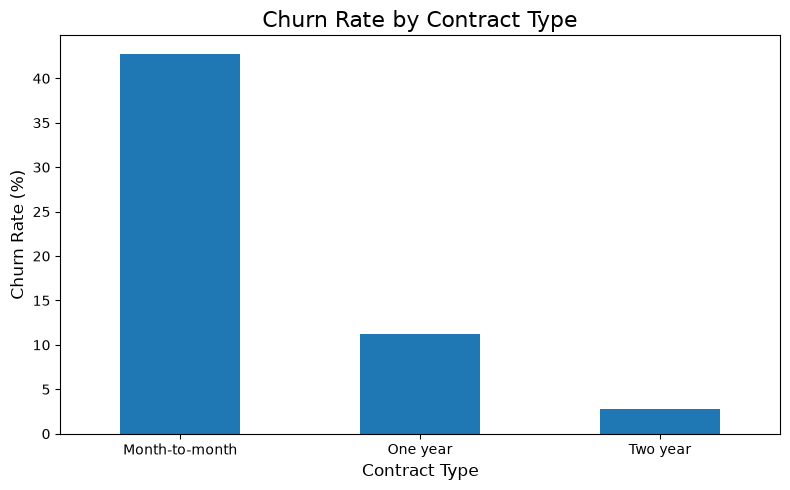

In [23]:
# Visualize churn rate by contract type

contract_churn_rate["Yes"].sort_values(ascending=False).plot(
    kind="bar",
    figsize=(8, 5)
)

plt.title("Churn Rate by Contract Type", fontsize=16)
plt.xlabel("Contract Type", fontsize=12)
plt.ylabel("Churn Rate (%)", fontsize=12)
plt.xticks(rotation=0)

plt.tight_layout()
plt.show()

In [24]:
# Create customer tenure groups

def tenure_group(tenure):
    if tenure <= 12:
        return "0-1 Year"
    elif tenure <= 24:
        return "1-2 Years"
    elif tenure <= 48:
        return "2-4 Years"
    elif tenure <= 60:
        return "4-5 Years"
    else:
        return "5+ Years"

df["TenureGroup"] = df["tenure"].apply(tenure_group)

print(df["TenureGroup"].value_counts())

TenureGroup
0-1 Year     2186
2-4 Years    1594
5+ Years     1407
1-2 Years    1024
4-5 Years     832
Name: count, dtype: int64


In [25]:
# Calculate churn rate by tenure group

tenure_churn_rate = pd.crosstab(
    df["TenureGroup"],
    df["Churn"],
    normalize="index"
) * 100

print("Churn Rate by Tenure Group (%):")
print(tenure_churn_rate)

Churn Rate by Tenure Group (%):
Churn               No        Yes
TenureGroup                      
0-1 Year     52.561757  47.438243
1-2 Years    71.289062  28.710938
2-4 Years    79.611041  20.388959
4-5 Years    85.576923  14.423077
5+ Years     93.390192   6.609808


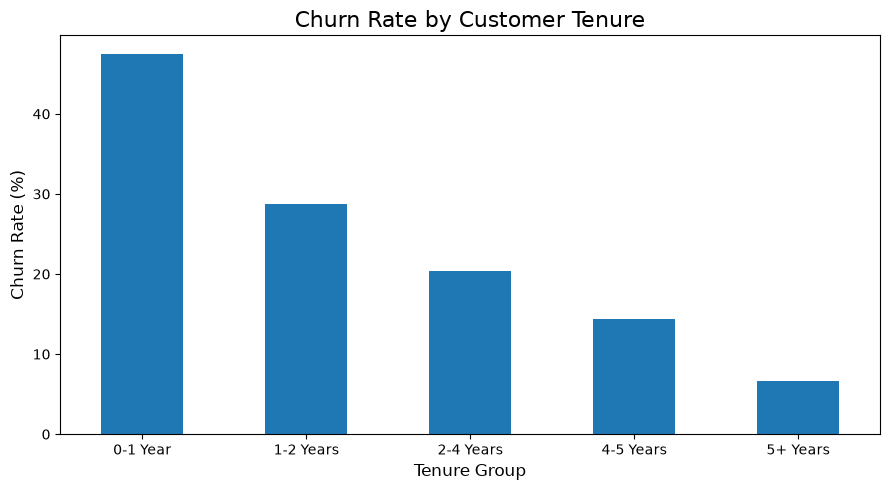

In [26]:
# Visualize churn rate by tenure group

tenure_order = [
    "0-1 Year",
    "1-2 Years",
    "2-4 Years",
    "4-5 Years",
    "5+ Years"
]

tenure_churn_rate.loc[tenure_order, "Yes"].plot(
    kind="bar",
    figsize=(9, 5)
)

plt.title("Churn Rate by Customer Tenure", fontsize=16)
plt.xlabel("Tenure Group", fontsize=12)
plt.ylabel("Churn Rate (%)", fontsize=12)
plt.xticks(rotation=0)

plt.tight_layout()
plt.show()

In [27]:
# Compare average monthly charges by churn

monthly_charges_churn = df.groupby("Churn")["MonthlyCharges"].mean()

print("Average Monthly Charges by Churn:")
print(monthly_charges_churn)

Average Monthly Charges by Churn:
Churn
No     61.265124
Yes    74.441332
Name: MonthlyCharges, dtype: float64


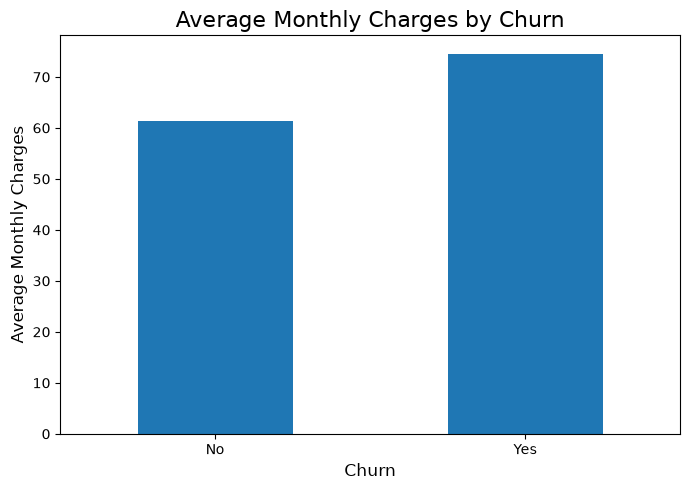

In [28]:
# Visualize average monthly charges by churn

monthly_charges_churn.plot(
    kind="bar",
    figsize=(7, 5)
)

plt.title("Average Monthly Charges by Churn", fontsize=16)
plt.xlabel("Churn", fontsize=12)
plt.ylabel("Average Monthly Charges", fontsize=12)
plt.xticks(rotation=0)

plt.tight_layout()
plt.show()

In [29]:
# Create monthly charge groups

def charge_group(charge):
    if charge < 35:
        return "Low (<35)"
    elif charge < 70:
        return "Medium (35-70)"
    else:
        return "High (70+)"

df["MonthlyChargeGroup"] = df["MonthlyCharges"].apply(charge_group)

print(df["MonthlyChargeGroup"].value_counts())

MonthlyChargeGroup
High (70+)        3591
Low (<35)         1731
Medium (35-70)    1721
Name: count, dtype: int64


In [30]:
# Calculate churn rate by monthly charge group

charge_churn_rate = pd.crosstab(
    df["MonthlyChargeGroup"],
    df["Churn"],
    normalize="index"
) * 100

print("Churn Rate by Monthly Charge Group (%):")
print(charge_churn_rate)

Churn Rate by Monthly Charge Group (%):
Churn                      No        Yes
MonthlyChargeGroup                      
High (70+)          64.522417  35.477583
Low (<35)           89.139226  10.860774
Medium (35-70)      76.350959  23.649041


In [31]:
# Calculate churn rate by Internet Service

internet_churn_rate = pd.crosstab(
    df["InternetService"],
    df["Churn"],
    normalize="index"
) * 100

print("Churn Rate by Internet Service (%):")
print(internet_churn_rate)

Churn Rate by Internet Service (%):
Churn                   No        Yes
InternetService                      
DSL              81.040892  18.959108
Fiber optic      58.107235  41.892765
No               92.595020   7.404980


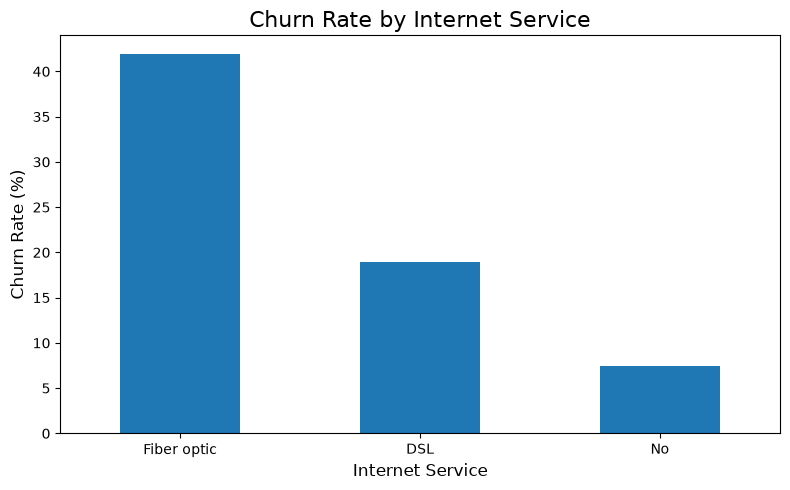

In [32]:
# Visualize churn rate by Internet Service

internet_churn_rate["Yes"].sort_values(ascending=False).plot(
    kind="bar",
    figsize=(8, 5)
)

plt.title("Churn Rate by Internet Service", fontsize=16)
plt.xlabel("Internet Service", fontsize=12)
plt.ylabel("Churn Rate (%)", fontsize=12)
plt.xticks(rotation=0)

plt.tight_layout()
plt.show()

In [33]:
# Customer count by Internet Service

print(df["InternetService"].value_counts())

InternetService
Fiber optic    3096
DSL            2421
No             1526
Name: count, dtype: int64


In [34]:
# Calculate churn rate by Online Security

security_churn_rate = pd.crosstab(
    df["OnlineSecurity"],
    df["Churn"],
    normalize="index"
) * 100

print("Churn Rate by Online Security (%):")
print(security_churn_rate)

Churn Rate by Online Security (%):
Churn                       No        Yes
OnlineSecurity                           
No                   58.233276  41.766724
No internet service  92.595020   7.404980
Yes                  85.388806  14.611194


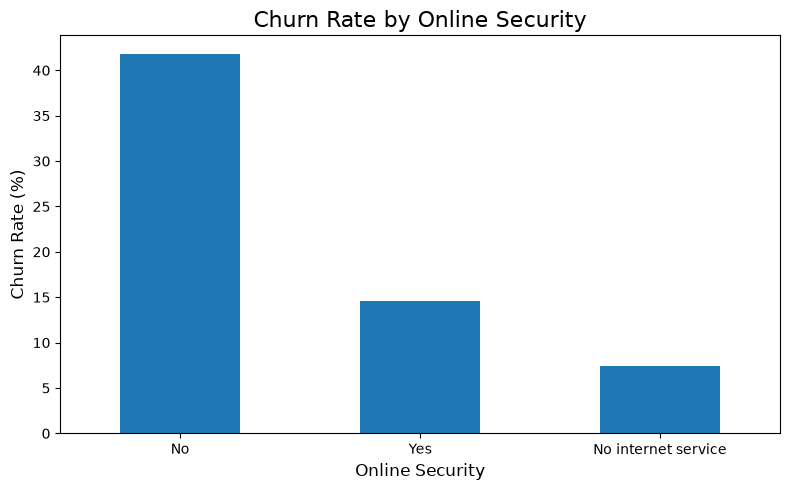

In [35]:
# Visualize churn rate by Online Security

security_churn_rate["Yes"].sort_values(ascending=False).plot(
    kind="bar",
    figsize=(8, 5)
)

plt.title("Churn Rate by Online Security", fontsize=16)
plt.xlabel("Online Security", fontsize=12)
plt.ylabel("Churn Rate (%)", fontsize=12)
plt.xticks(rotation=0)

plt.tight_layout()
plt.show()

In [36]:
# Customer count by Online Security

print(df["OnlineSecurity"].value_counts())

OnlineSecurity
No                     3498
Yes                    2019
No internet service    1526
Name: count, dtype: int64


In [37]:
# Calculate churn rate by Tech Support

techsupport_churn_rate = pd.crosstab(
    df["TechSupport"],
    df["Churn"],
    normalize="index"
) * 100

print("Churn Rate by Tech Support (%):")
print(techsupport_churn_rate)

Churn Rate by Tech Support (%):
Churn                       No        Yes
TechSupport                              
No                   58.364526  41.635474
No internet service  92.595020   7.404980
Yes                  84.833659  15.166341


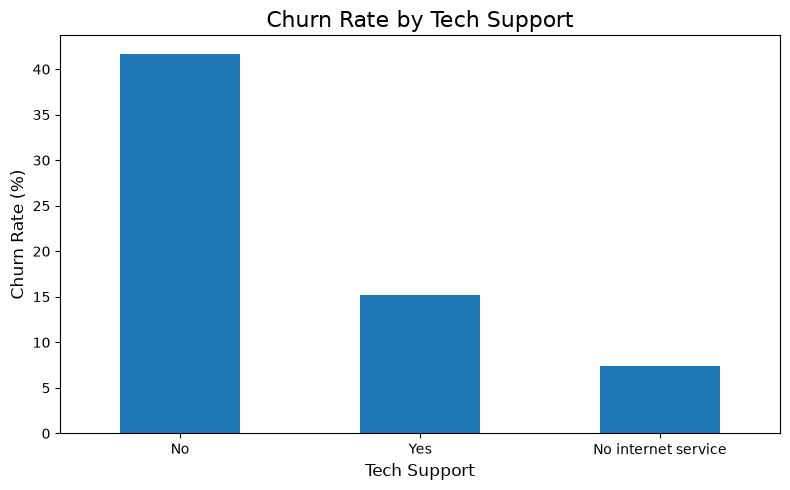

In [38]:
# Visualize churn rate by Tech Support

techsupport_churn_rate["Yes"].sort_values(ascending=False).plot(
    kind="bar",
    figsize=(8, 5)
)

plt.title("Churn Rate by Tech Support", fontsize=16)
plt.xlabel("Tech Support", fontsize=12)
plt.ylabel("Churn Rate (%)", fontsize=12)
plt.xticks(rotation=0)

plt.tight_layout()
plt.show()

In [39]:
# Customer count by Tech Support

print(df["TechSupport"].value_counts())

TechSupport
No                     3473
Yes                    2044
No internet service    1526
Name: count, dtype: int64


In [40]:
# Calculate churn rate by payment method

payment_churn_rate = pd.crosstab(
    df["PaymentMethod"],
    df["Churn"],
    normalize="index"
) * 100

print("Churn Rate by Payment Method (%):")
print(payment_churn_rate)

Churn Rate by Payment Method (%):
Churn                             No        Yes
PaymentMethod                                  
Bank transfer (automatic)  83.290155  16.709845
Credit card (automatic)    84.756899  15.243101
Electronic check           54.714588  45.285412
Mailed check               80.893300  19.106700


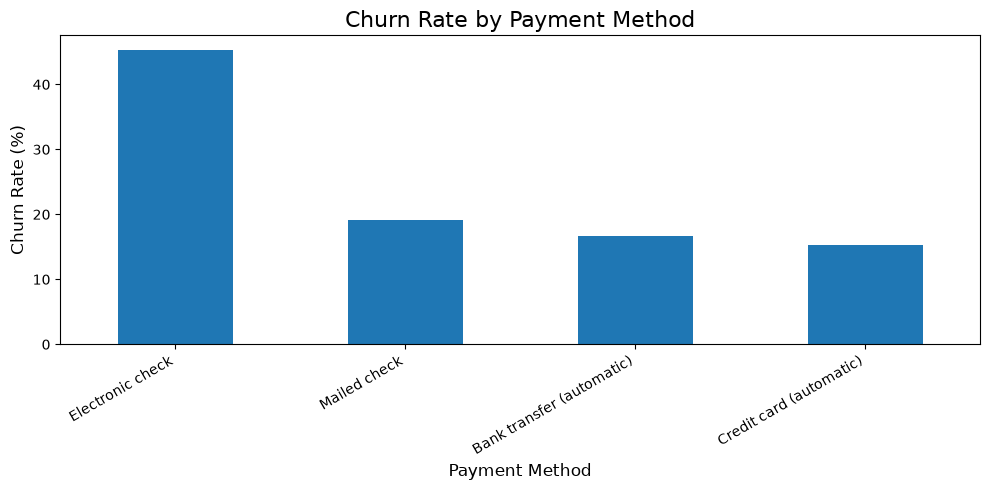

In [41]:
# Visualize churn rate by payment method

payment_churn_rate["Yes"].sort_values(ascending=False).plot(
    kind="bar",
    figsize=(10, 5)
)

plt.title("Churn Rate by Payment Method", fontsize=16)
plt.xlabel("Payment Method", fontsize=12)
plt.ylabel("Churn Rate (%)", fontsize=12)
plt.xticks(rotation=30, ha="right")

plt.tight_layout()
plt.show()

In [42]:
# Customer count by payment method

print(df["PaymentMethod"].value_counts())

PaymentMethod
Electronic check             2365
Mailed check                 1612
Bank transfer (automatic)    1544
Credit card (automatic)      1522
Name: count, dtype: int64


In [43]:
# Calculate churn rate by Partner

partner_churn_rate = pd.crosstab(
    df["Partner"],
    df["Churn"],
    normalize="index"
) * 100

print("Churn Rate by Partner (%):")
print(partner_churn_rate)

Churn Rate by Partner (%):
Churn           No        Yes
Partner                      
No       67.042021  32.957979
Yes      80.335097  19.664903


In [44]:
# Calculate churn rate by Dependents

dependents_churn_rate = pd.crosstab(
    df["Dependents"],
    df["Churn"],
    normalize="index"
) * 100

print("Churn Rate by Dependents (%):")
print(dependents_churn_rate)

Churn Rate by Dependents (%):
Churn              No        Yes
Dependents                      
No          68.720860  31.279140
Yes         84.549763  15.450237


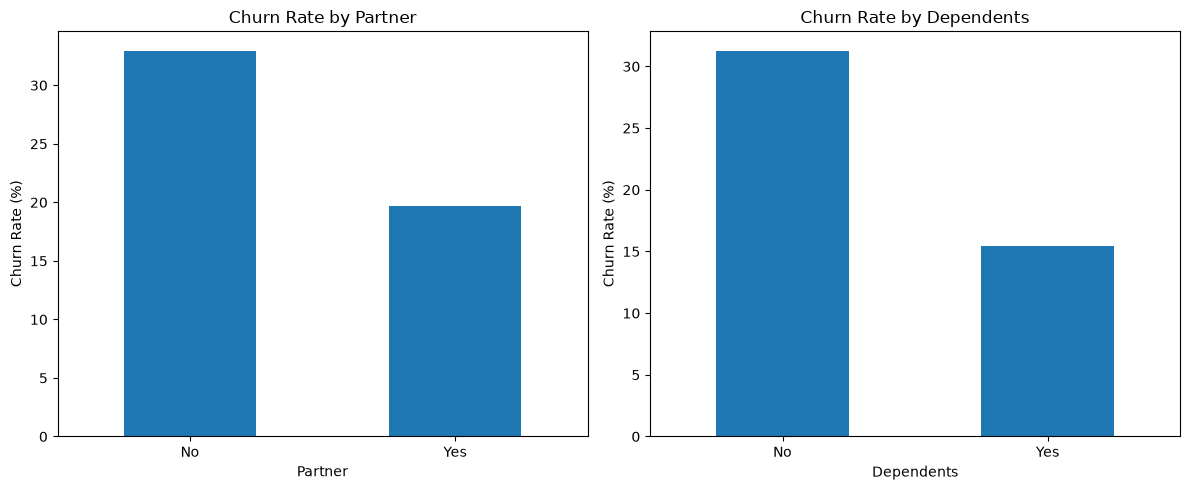

In [45]:
# Visualize churn rate by Partner and Dependents

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

partner_churn_rate["Yes"].plot(
    kind="bar",
    ax=axes[0]
)

axes[0].set_title("Churn Rate by Partner")
axes[0].set_xlabel("Partner")
axes[0].set_ylabel("Churn Rate (%)")
axes[0].tick_params(axis="x", rotation=0)

dependents_churn_rate["Yes"].plot(
    kind="bar",
    ax=axes[1]
)

axes[1].set_title("Churn Rate by Dependents")
axes[1].set_xlabel("Dependents")
axes[1].set_ylabel("Churn Rate (%)")
axes[1].tick_params(axis="x", rotation=0)

plt.tight_layout()
plt.show()

In [6]:
df = pd.read_csv("../Dataset/Telco_Customer_Churn.csv")

In [7]:
df = pd.read_csv("../Dataset/Telco_Customer_Churn.csv")

In [8]:
print(df.shape)

(7043, 21)


In [9]:
# Calculate churn rate by Phone Service

phone_churn_rate = pd.crosstab(
    df["PhoneService"],
    df["Churn"],
    normalize="index"
) * 100

print("Churn Rate by Phone Service (%):")
print(phone_churn_rate)

Churn Rate by Phone Service (%):
Churn                No        Yes
PhoneService                      
No            75.073314  24.926686
Yes           73.290363  26.709637


In [10]:
# Calculate churn rate by Internet Service

internet_churn_rate = pd.crosstab(
    df["InternetService"],
    df["Churn"],
    normalize="index"
) * 100

print("Churn Rate by Internet Service (%):")
print(internet_churn_rate)

Churn Rate by Internet Service (%):
Churn                   No        Yes
InternetService                      
DSL              81.040892  18.959108
Fiber optic      58.107235  41.892765
No               92.595020   7.404980


In [11]:
# Calculate churn rate by Contract Type

contract_churn_rate = pd.crosstab(
    df["Contract"],
    df["Churn"],
    normalize="index"
) * 100

print("Churn Rate by Contract Type (%):")
print(contract_churn_rate)

Churn Rate by Contract Type (%):
Churn                  No        Yes
Contract                            
Month-to-month  57.290323  42.709677
One year        88.730482  11.269518
Two year        97.168142   2.831858


In [12]:
# Calculate churn rate by Payment Method

payment_churn_rate = pd.crosstab(
    df["PaymentMethod"],
    df["Churn"],
    normalize="index"
) * 100

print("Churn Rate by Payment Method (%):")
print(payment_churn_rate)

Churn Rate by Payment Method (%):
Churn                             No        Yes
PaymentMethod                                  
Bank transfer (automatic)  83.290155  16.709845
Credit card (automatic)    84.756899  15.243101
Electronic check           54.714588  45.285412
Mailed check               80.893300  19.106700


In [13]:
# Calculate churn rate by Tenure Groups

df["TenureGroup"] = pd.cut(
    df["tenure"],
    bins=[-1, 12, 24, 48, 60, 100],
    labels=["0-1 Year", "1-2 Years", "2-4 Years", "4-5 Years", "5+ Years"]
)

tenure_churn_rate = pd.crosstab(
    df["TenureGroup"],
    df["Churn"],
    normalize="index"
) * 100

print("Churn Rate by Tenure Group (%):")
print(tenure_churn_rate)

Churn Rate by Tenure Group (%):
Churn               No        Yes
TenureGroup                      
0-1 Year     52.561757  47.438243
1-2 Years    71.289062  28.710938
2-4 Years    79.611041  20.388959
4-5 Years    85.576923  14.423077
5+ Years     93.390192   6.609808


In [14]:
# Create Monthly Charges Groups

df["MonthlyChargesGroup"] = pd.cut(
    df["MonthlyCharges"],
    bins=[0, 30, 60, 90, 120],
    labels=["Low", "Medium", "High", "Very High"]
)

# Calculate churn rate by Monthly Charges Group

monthly_charges_churn = pd.crosstab(
    df["MonthlyChargesGroup"],
    df["Churn"],
    normalize="index"
) * 100

print("Churn Rate by Monthly Charges Group (%):")
print(monthly_charges_churn)

Churn Rate by Monthly Charges Group (%):
Churn                       No        Yes
MonthlyChargesGroup                      
Low                  90.199637   9.800363
Medium               74.071146  25.928854
High                 66.093881  33.906119
Very High            67.222542  32.777458


In [15]:
# Calculate churn rate by Senior Citizen status

senior_churn_rate = pd.crosstab(
    df["SeniorCitizen"],
    df["Churn"],
    normalize="index"
) * 100

print("Churn Rate by Senior Citizen (%):")
print(senior_churn_rate)

Churn Rate by Senior Citizen (%):
Churn                 No        Yes
SeniorCitizen                      
0              76.393832  23.606168
1              58.318739  41.681261


In [16]:
# Calculate churn rate by Gender

gender_churn_rate = pd.crosstab(
    df["gender"],
    df["Churn"],
    normalize="index"
) * 100

print("Churn Rate by Gender (%):")
print(gender_churn_rate)

Churn Rate by Gender (%):
Churn          No        Yes
gender                      
Female  73.079128  26.920872
Male    73.839662  26.160338


In [17]:
# Calculate churn rate by Partner status

partner_churn_rate = pd.crosstab(
    df["Partner"],
    df["Churn"],
    normalize="index"
) * 100

print("Churn Rate by Partner Status (%):")
print(partner_churn_rate)

Churn Rate by Partner Status (%):
Churn           No        Yes
Partner                      
No       67.042021  32.957979
Yes      80.335097  19.664903


In [18]:
# Calculate churn rate by Dependents status

dependents_churn_rate = pd.crosstab(
    df["Dependents"],
    df["Churn"],
    normalize="index"
) * 100

print("Churn Rate by Dependents Status (%):")
print(dependents_churn_rate)

Churn Rate by Dependents Status (%):
Churn              No        Yes
Dependents                      
No          68.720860  31.279140
Yes         84.549763  15.450237


In [19]:
# Create a combined service support group

df["Security_TechSupport"] = (
    df["OnlineSecurity"] + " + " + df["TechSupport"]
)

# Calculate churn rate

support_churn_rate = pd.crosstab(
    df["Security_TechSupport"],
    df["Churn"],
    normalize="index"
) * 100

print("Churn Rate by Online Security + Tech Support (%):")
print(support_churn_rate.sort_values("Yes", ascending=False))

Churn Rate by Online Security + Tech Support (%):
Churn                                             No        Yes
Security_TechSupport                                           
No + No                                    51.037995  48.962005
No + Yes                                   77.671958  22.328042
Yes + No                                   78.695652  21.304348
Yes + Yes                                  90.991811   9.008189
No internet service + No internet service  92.595020   7.404980


In [20]:
# Create monthly charge groups

df["ChargeGroup"] = pd.cut(
    df["MonthlyCharges"],
    bins=[0, 40, 80, 120],
    labels=["Low", "Medium", "High"]
)

print(df["ChargeGroup"].value_counts())

ChargeGroup
High      2666
Medium    2539
Low       1838
Name: count, dtype: int64


In [21]:
# Analyze churn by Contract, Tenure and Monthly Charges

high_risk_segments = pd.crosstab(
    [
        df["Contract"],
        df["TenureGroup"],
        df["ChargeGroup"]
    ],
    df["Churn"],
    normalize="index"
) * 100

print("Churn Rate by Contract + Tenure + Charge Group:")
print(
    high_risk_segments
    .sort_values("Yes", ascending=False)
    .head(15)
)

Churn Rate by Contract + Tenure + Charge Group:
Churn                                          No        Yes
Contract       TenureGroup ChargeGroup                      
Month-to-month 0-1 Year    High         26.508621  73.491379
                           Medium       47.791165  52.208835
               1-2 Years   High         48.275862  51.724138
               2-4 Years   High         57.305936  42.694064
               5+ Years    Low          66.666667  33.333333
               1-2 Years   Medium       68.135593  31.864407
               4-5 Years   High         68.627451  31.372549
               0-1 Year    Low          69.475655  30.524345
One year       0-1 Year    High         71.428571  28.571429
Month-to-month 5+ Years    High         74.725275  25.274725
               2-4 Years   Medium       76.556777  23.443223
               4-5 Years   Medium       77.142857  22.857143
One year       1-2 Years   High         78.260870  21.739130
               4-5 Years   High      

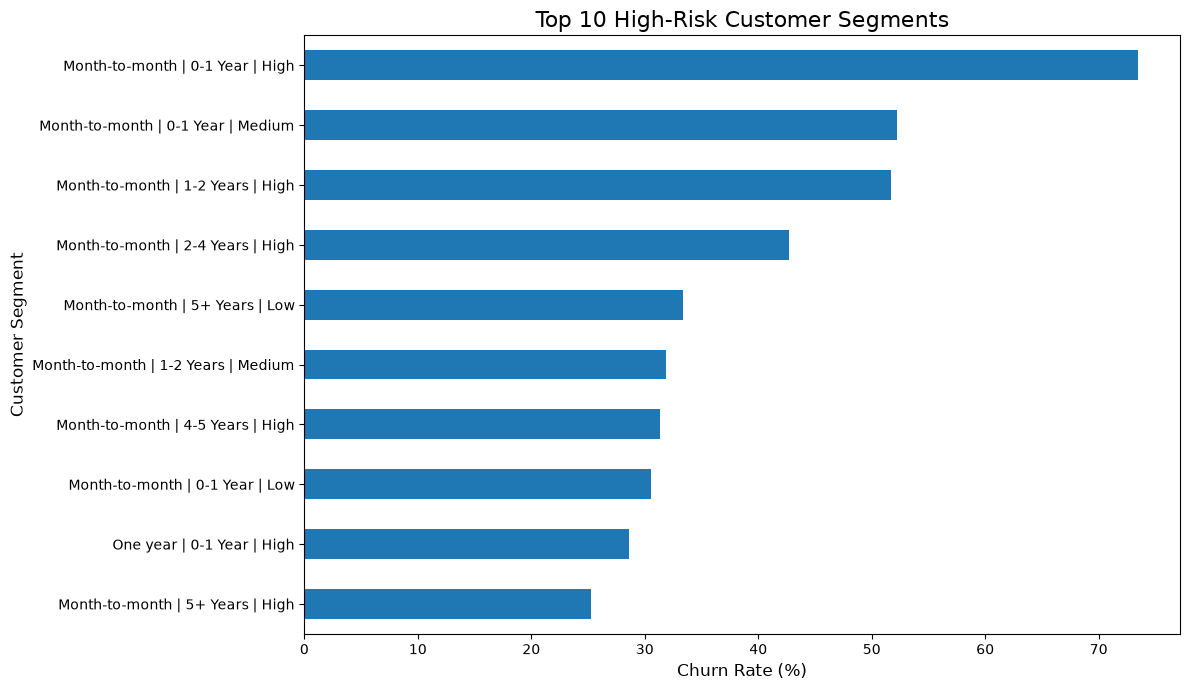

In [38]:
# Visualize the top 10 high-risk customer segments

top_risk = (
    high_risk_segments["Yes"]
    .sort_values(ascending=False)
    .head(10)
    .sort_values()
)

top_risk.index = [
    " | ".join(map(str, index))
    for index in top_risk.index
]

plt.figure(figsize=(12, 7))

top_risk.plot(kind="barh")

plt.title("Top 10 High-Risk Customer Segments", fontsize=16)
plt.xlabel("Churn Rate (%)", fontsize=12)
plt.ylabel("Customer Segment", fontsize=12)

plt.tight_layout()
plt.show()

In [23]:
# Calculate churn rate by Payment Method

payment_churn_rate = pd.crosstab(
    df["PaymentMethod"],
    df["Churn"],
    normalize="index"
) * 100

print("Churn Rate by Payment Method (%):")
print(payment_churn_rate)

Churn Rate by Payment Method (%):
Churn                             No        Yes
PaymentMethod                                  
Bank transfer (automatic)  83.290155  16.709845
Credit card (automatic)    84.756899  15.243101
Electronic check           54.714588  45.285412
Mailed check               80.893300  19.106700


In [24]:
# Calculate churn rate by Paperless Billing

paperless_churn_rate = pd.crosstab(
    df["PaperlessBilling"],
    df["Churn"],
    normalize="index"
) * 100

print("Churn Rate by Paperless Billing (%):")
print(paperless_churn_rate)

Churn Rate by Paperless Billing (%):
Churn                    No        Yes
PaperlessBilling                      
No                83.669916  16.330084
Yes               66.434908  33.565092


In [25]:
# Calculate churn rate by Online Security

security_churn_rate = pd.crosstab(
    df["OnlineSecurity"],
    df["Churn"],
    normalize="index"
) * 100

print("Churn Rate by Online Security (%):")
print(security_churn_rate)

Churn Rate by Online Security (%):
Churn                       No        Yes
OnlineSecurity                           
No                   58.233276  41.766724
No internet service  92.595020   7.404980
Yes                  85.388806  14.611194


In [26]:
# Calculate churn rate by Online Backup

backup_churn_rate = pd.crosstab(
    df["OnlineBackup"],
    df["Churn"],
    normalize="index"
) * 100

print("Churn Rate by Online Backup (%):")
print(backup_churn_rate)

Churn Rate by Online Backup (%):
Churn                       No        Yes
OnlineBackup                             
No                   60.071244  39.928756
No internet service  92.595020   7.404980
Yes                  78.468506  21.531494


In [27]:
# Calculate churn rate by Device Protection

device_churn_rate = pd.crosstab(
    df["DeviceProtection"],
    df["Churn"],
    normalize="index"
) * 100

print("Churn Rate by Device Protection (%):")
print(device_churn_rate)

Churn Rate by Device Protection (%):
Churn                       No        Yes
DeviceProtection                         
No                   60.872375  39.127625
No internet service  92.595020   7.404980
Yes                  77.497936  22.502064


In [28]:
# Calculate churn rate by Tech Support

techsupport_churn_rate = pd.crosstab(
    df["TechSupport"],
    df["Churn"],
    normalize="index"
) * 100

print("Churn Rate by Tech Support (%):")
print(techsupport_churn_rate)

Churn Rate by Tech Support (%):
Churn                       No        Yes
TechSupport                              
No                   58.364526  41.635474
No internet service  92.595020   7.404980
Yes                  84.833659  15.166341


In [29]:
# Calculate churn rate by Streaming TV

streaming_tv_churn = pd.crosstab(
    df["StreamingTV"],
    df["Churn"],
    normalize="index"
) * 100

print("Churn Rate by Streaming TV (%):")
print(streaming_tv_churn)

Churn Rate by Streaming TV (%):
Churn                       No        Yes
StreamingTV                              
No                   66.476868  33.523132
No internet service  92.595020   7.404980
Yes                  69.929812  30.070188


In [30]:
# Calculate churn rate by Streaming Movies

streaming_movies_churn = pd.crosstab(
    df["StreamingMovies"],
    df["Churn"],
    normalize="index"
) * 100

print("Churn Rate by Streaming Movies (%):")
print(streaming_movies_churn)

Churn Rate by Streaming Movies (%):
Churn                       No        Yes
StreamingMovies                          
No                   66.319569  33.680431
No internet service  92.595020   7.404980
Yes                  70.058565  29.941435


In [33]:
# Convert numerical columns to numeric data types

df["tenure"] = pd.to_numeric(df["tenure"], errors="coerce")
df["MonthlyCharges"] = pd.to_numeric(df["MonthlyCharges"], errors="coerce")
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")

print("Numerical columns converted successfully.")

print("\nData types:")
print(df[["tenure", "MonthlyCharges", "TotalCharges"]].dtypes)

Numerical columns converted successfully.

Data types:
tenure              int64
MonthlyCharges    float64
TotalCharges      float64
dtype: object


In [34]:
# Compare numerical characteristics of churned vs retained customers

churn_summary = df.groupby("Churn")[
    ["tenure", "MonthlyCharges", "TotalCharges"]
].mean()

print("Average Customer Characteristics by Churn:")
print(churn_summary)

Average Customer Characteristics by Churn:
          tenure  MonthlyCharges  TotalCharges
Churn                                         
No     37.569965       61.265124   2555.344141
Yes    17.979133       74.441332   1531.796094


In [35]:
# Correlation analysis of numerical variables

correlation_matrix = df[
    ["tenure", "MonthlyCharges", "TotalCharges"]
].corr()

print("Correlation Matrix:")
print(correlation_matrix)

Correlation Matrix:
                 tenure  MonthlyCharges  TotalCharges
tenure          1.00000        0.247900      0.825880
MonthlyCharges  0.24790        1.000000      0.651065
TotalCharges    0.82588        0.651065      1.000000


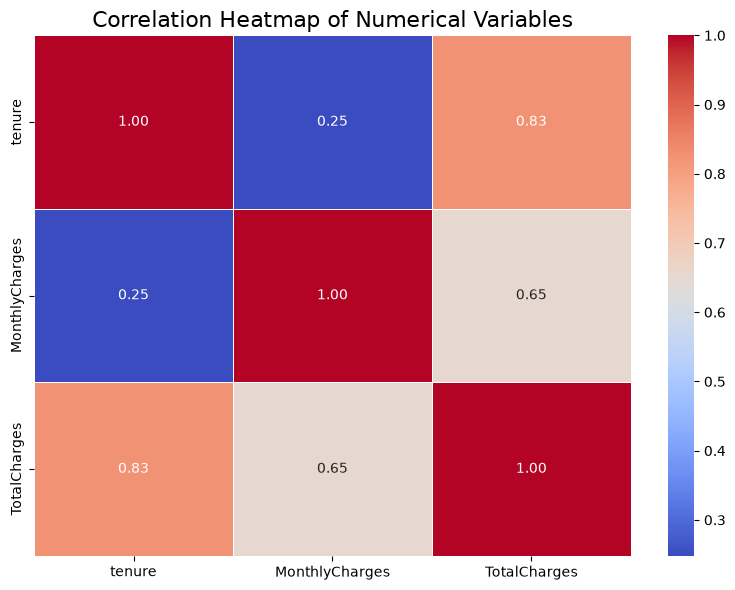

In [37]:
# Create correlation heatmap

plt.figure(figsize=(8, 6))

sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    linewidths=0.5
)

plt.title("Correlation Heatmap of Numerical Variables", fontsize=16)
plt.tight_layout()
plt.show()

In [39]:
# Key churn drivers identified from the analysis

print("KEY CUSTOMER CHURN DRIVERS")
print("=" * 50)

print("\n1. Contract Type")
print("Month-to-month customers show the highest churn risk.")

print("\n2. Tenure")
print("Customers with shorter tenure are more likely to churn.")

print("\n3. Internet Service")
print("Fiber optic customers show higher churn than DSL customers.")

print("\n4. Monthly Charges")
print("Churned customers have higher average monthly charges.")

print("\n5. Tech Support & Online Security")
print("Customers without additional support/security services show higher churn risk.")

print("\n6. Payment & Billing")
print("Payment method and paperless billing are associated with different churn levels.")

print("\n7. High-Risk Segments")
print("New customers with month-to-month contracts and other risk factors require priority retention efforts.")

KEY CUSTOMER CHURN DRIVERS

1. Contract Type
Month-to-month customers show the highest churn risk.

2. Tenure
Customers with shorter tenure are more likely to churn.

3. Internet Service
Fiber optic customers show higher churn than DSL customers.

4. Monthly Charges
Churned customers have higher average monthly charges.

5. Tech Support & Online Security
Customers without additional support/security services show higher churn risk.

6. Payment & Billing
Payment method and paperless billing are associated with different churn levels.

7. High-Risk Segments
New customers with month-to-month contracts and other risk factors require priority retention efforts.


In [40]:
# Create final EDA summary table

eda_summary = pd.DataFrame({
    "Churn Driver": [
        "Contract Type",
        "Tenure",
        "Internet Service",
        "Monthly Charges",
        "Tech Support",
        "Online Security",
        "Payment Method",
        "Paperless Billing"
    ],
    
    "Key Finding": [
        "Month-to-month customers have the highest churn risk.",
        "Customers with shorter tenure are more likely to churn.",
        "Fiber optic customers show higher churn than DSL customers.",
        "Churned customers have higher average monthly charges.",
        "Customers without Tech Support have higher churn risk.",
        "Customers without Online Security have higher churn risk.",
        "Churn varies across different payment methods.",
        "Paperless billing customers show different churn levels."
    ]
})

print("FINAL EDA SUMMARY")
print("=" * 80)
display(eda_summary)

FINAL EDA SUMMARY


,Churn Driver,Key Finding
0,Contract Type,Month-to-month customers have the highest chur...
1,Tenure,Customers with shorter tenure are more likely ...
2,Internet Service,Fiber optic customers show higher churn than D...
3,Monthly Charges,Churned customers have higher average monthly ...
4,Tech Support,Customers without Tech Support have higher chu...
5,Online Security,Customers without Online Security have higher ...
6,Payment Method,Churn varies across different payment methods.
7,Paperless Billing,Paperless billing customers show different chu...


In [41]:
# Create customer tenure groups

df["TenureGroup"] = pd.cut(
    df["tenure"],
    bins=[-1, 12, 24, 48, 72],
    labels=["0-1 Year", "1-2 Years", "2-4 Years", "4-6 Years"]
)

print("Customer Tenure Groups:")
print(df["TenureGroup"].value_counts().sort_index())

Customer Tenure Groups:
TenureGroup
0-1 Year     2186
1-2 Years    1024
2-4 Years    1594
4-6 Years    2239
Name: count, dtype: int64


In [42]:
# Create customer risk segments

def risk_segment(row):
    score = 0

    # Contract risk
    if row["Contract"] == "Month-to-month":
        score += 2
    elif row["Contract"] == "One year":
        score += 1

    # Tenure risk
    if row["tenure"] <= 12:
        score += 2
    elif row["tenure"] <= 24:
        score += 1

    # Monthly charge risk
    if row["MonthlyCharges"] >= 80:
        score += 2
    elif row["MonthlyCharges"] >= 50:
        score += 1

    # Assign risk level
    if score >= 5:
        return "High Risk"
    elif score >= 3:
        return "Medium Risk"
    else:
        return "Low Risk"


df["RiskSegment"] = df.apply(risk_segment, axis=1)

print("Customer Risk Segment Distribution:")
print(df["RiskSegment"].value_counts())

Customer Risk Segment Distribution:
RiskSegment
Medium Risk    2929
Low Risk       2568
High Risk      1546
Name: count, dtype: int64


In [43]:
# Calculate churn rate by risk segment

risk_churn_rate = pd.crosstab(
    df["RiskSegment"],
    df["Churn"],
    normalize="index"
) * 100

print("Churn Rate by Risk Segment (%):")
print(risk_churn_rate)

Churn Rate by Risk Segment (%):
Churn               No        Yes
RiskSegment                      
High Risk    40.944373  59.055627
Low Risk     95.716511   4.283489
Medium Risk  71.116422  28.883578


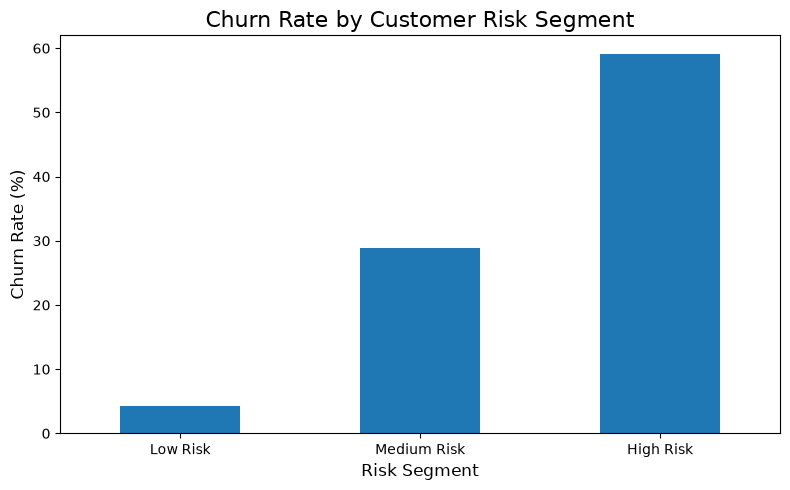

In [44]:
# Visualize churn rate by risk segment

risk_churn_rate["Yes"].reindex(
    ["Low Risk", "Medium Risk", "High Risk"]
).plot(
    kind="bar",
    figsize=(8, 5)
)

plt.title("Churn Rate by Customer Risk Segment", fontsize=16)
plt.xlabel("Risk Segment", fontsize=12)
plt.ylabel("Churn Rate (%)", fontsize=12)
plt.xticks(rotation=0)

plt.tight_layout()
plt.show()

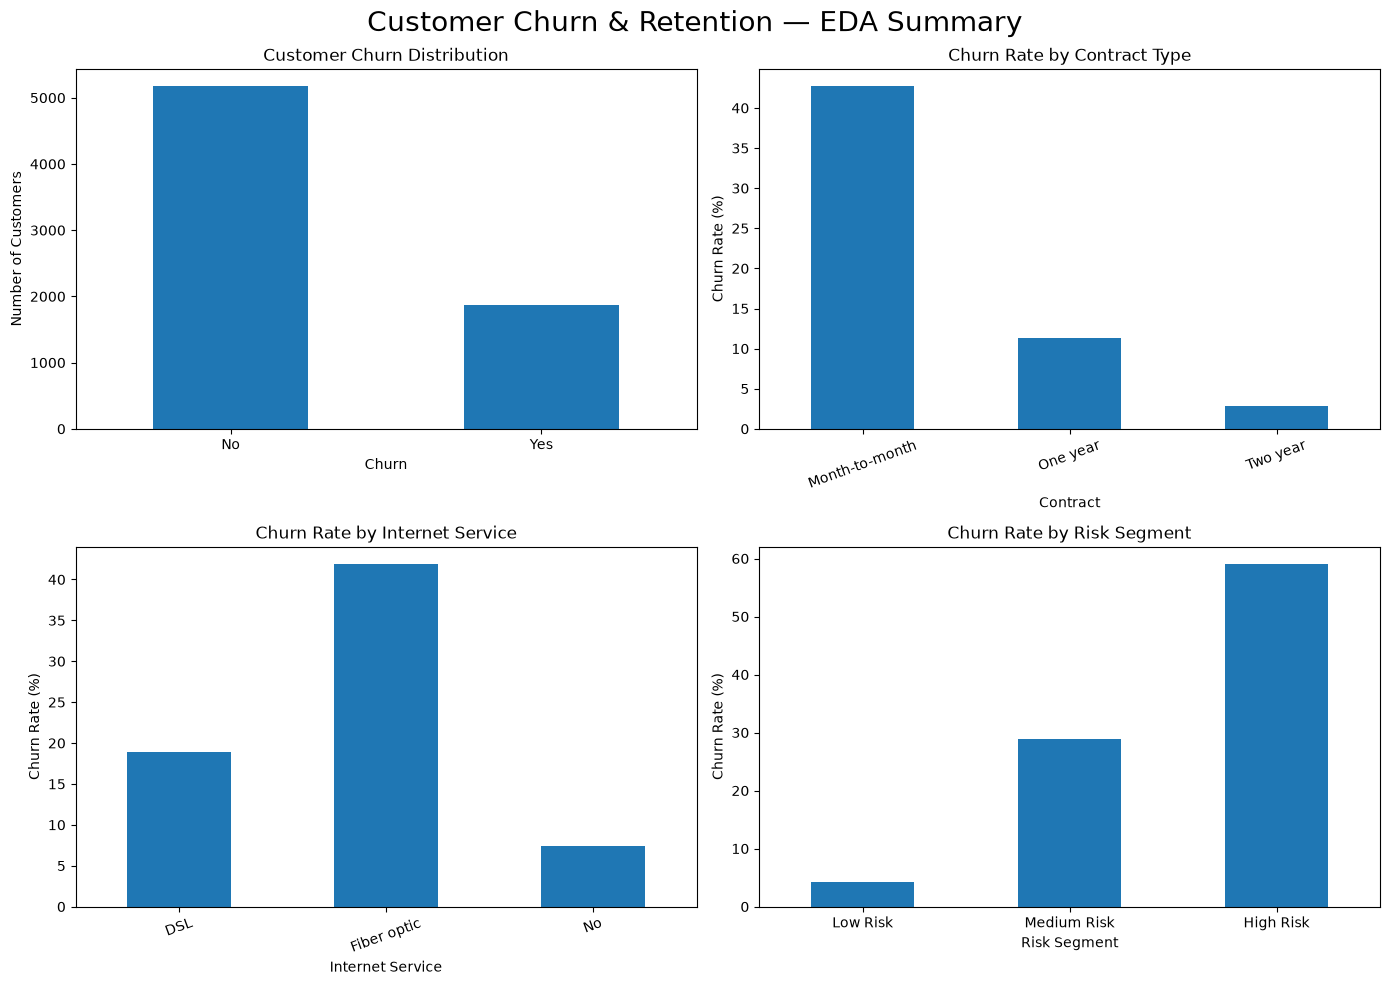

In [45]:
# Final EDA Summary Dashboard

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. Churn Distribution
df["Churn"].value_counts().plot(
    kind="bar",
    ax=axes[0, 0]
)
axes[0, 0].set_title("Customer Churn Distribution")
axes[0, 0].set_xlabel("Churn")
axes[0, 0].set_ylabel("Number of Customers")
axes[0, 0].tick_params(axis="x", rotation=0)

# 2. Contract Churn
contract_churn_rate["Yes"].plot(
    kind="bar",
    ax=axes[0, 1]
)
axes[0, 1].set_title("Churn Rate by Contract Type")
axes[0, 1].set_xlabel("Contract")
axes[0, 1].set_ylabel("Churn Rate (%)")
axes[0, 1].tick_params(axis="x", rotation=20)

# 3. Internet Service Churn
internet_churn_rate["Yes"].plot(
    kind="bar",
    ax=axes[1, 0]
)
axes[1, 0].set_title("Churn Rate by Internet Service")
axes[1, 0].set_xlabel("Internet Service")
axes[1, 0].set_ylabel("Churn Rate (%)")
axes[1, 0].tick_params(axis="x", rotation=20)

# 4. Risk Segment Churn
risk_churn_rate["Yes"].reindex(
    ["Low Risk", "Medium Risk", "High Risk"]
).plot(
    kind="bar",
    ax=axes[1, 1]
)
axes[1, 1].set_title("Churn Rate by Risk Segment")
axes[1, 1].set_xlabel("Risk Segment")
axes[1, 1].set_ylabel("Churn Rate (%)")
axes[1, 1].tick_params(axis="x", rotation=0)

plt.suptitle(
    "Customer Churn & Retention — EDA Summary",
    fontsize=20
)

plt.tight_layout()
plt.show()

In [46]:
# Final Business Recommendations

print("CUSTOMER CHURN & RETENTION — BUSINESS RECOMMENDATIONS")
print("=" * 65)

print("\n1. Strengthen Month-to-Month Customer Retention")
print("Offer incentives, discounts, or contract benefits to encourage")
print("month-to-month customers to move to longer-term contracts.")

print("\n2. Improve Early-Tenure Customer Engagement")
print("Focus onboarding, welcome programs, and early support on new")
print("customers because shorter-tenure customers show higher churn risk.")

print("\n3. Investigate High Fiber-Optic Churn")
print("Review pricing, service quality, technical issues, and customer")
print("experience among fiber-optic customers.")

print("\n4. Review High Monthly Charges")
print("Identify customers with high monthly charges and offer suitable")
print("plans, bundles, or loyalty incentives.")

print("\n5. Strengthen Customer Support & Security Services")
print("Promote Online Security and Tech Support services to customers")
print("who may benefit from additional support.")

print("\n6. Target High-Risk Customer Segments")
print("Prioritize retention campaigns for customers with multiple")
print("risk factors such as short tenure, month-to-month contracts,")
print("and high monthly charges.")

print("\n7. Build a Proactive Retention Program")
print("Use customer risk segments to identify at-risk customers")
print("before they churn and trigger targeted retention actions.")

CUSTOMER CHURN & RETENTION — BUSINESS RECOMMENDATIONS

1. Strengthen Month-to-Month Customer Retention
Offer incentives, discounts, or contract benefits to encourage
month-to-month customers to move to longer-term contracts.

2. Improve Early-Tenure Customer Engagement
Focus onboarding, welcome programs, and early support on new
customers because shorter-tenure customers show higher churn risk.

3. Investigate High Fiber-Optic Churn
Review pricing, service quality, technical issues, and customer
experience among fiber-optic customers.

4. Review High Monthly Charges
Identify customers with high monthly charges and offer suitable
plans, bundles, or loyalty incentives.

5. Strengthen Customer Support & Security Services
Promote Online Security and Tech Support services to customers
who may benefit from additional support.

6. Target High-Risk Customer Segments
Prioritize retention campaigns for customers with multiple
risk factors such as short tenure, month-to-month contracts,
and high 

In [47]:
# Save the cleaned dataset

output_file = "../Dataset/Telco_Customer_Churn_Cleaned.csv"

df.to_csv(output_file, index=False)

print("Cleaned dataset saved successfully!")
print("File:", output_file)

Cleaned dataset saved successfully!
File: ../Dataset/Telco_Customer_Churn_Cleaned.csv


# Customer Churn & Retention Analysis

## 1. Executive Summary

This project analyzes customer churn behavior to understand why customers leave,
which customer segments are at higher risk, and what actions a business can take
to improve customer retention.

The analysis was performed using Python with Pandas, NumPy, Matplotlib, and Seaborn.

---

## 2. Business Question

Why are customers leaving, which customers are at risk, and what can the company
do to retain them?

---

## 3. Analysis Areas

The analysis covers:

- Customer demographics
- Customer tenure
- Monthly charges
- Contract type
- Internet and support services
- Payment methods
- Customer churn
- High-risk customer segments

---

## 4. Data Preparation

The dataset was inspected for:

- Missing values
- Duplicate records
- Incorrect data types
- Blank values

The `TotalCharges` column was converted from text to numeric format and missing
values associated with zero-tenure customers were handled appropriately.

---

## 5. Key Findings

### Contract Type

Month-to-month customers show substantially higher churn than customers with
one-year and two-year contracts.

### Customer Tenure

Customers with shorter tenure are more likely to churn than long-term customers.

### Internet Service

Fiber optic customers show a higher churn rate than DSL and customers without
internet service.

### Monthly Charges

Churned customers have higher average monthly charges than retained customers.

### Customer Support

Customers without services such as Online Security and Tech Support show
higher churn risk.

### Payment & Billing

Churn varies across payment methods and billing preferences.

### High-Risk Customers

Customers with multiple risk factors, including short tenure, month-to-month
contracts, and higher monthly charges, should receive priority retention
attention.

---

## 6. Business Recommendations

1. Encourage month-to-month customers to move toward longer-term contracts.
2. Strengthen onboarding and engagement during the first year.
3. Investigate service quality and pricing among high-churn fiber customers.
4. Review pricing and plan options for customers with high monthly charges.
5. Promote useful security and technical support services.
6. Create targeted retention campaigns for high-risk customer segments.
7. Develop a proactive churn monitoring system.

---

## 7. Tools Used

- Python
- Pandas
- NumPy
- Matplotlib
- Seaborn
- Jupyter Notebook

---

## 8. Project Outcome

The analysis identified major customer churn drivers and translated the findings
into actionable retention strategies.

The cleaned dataset can be used for further analysis and Power BI dashboard
development.

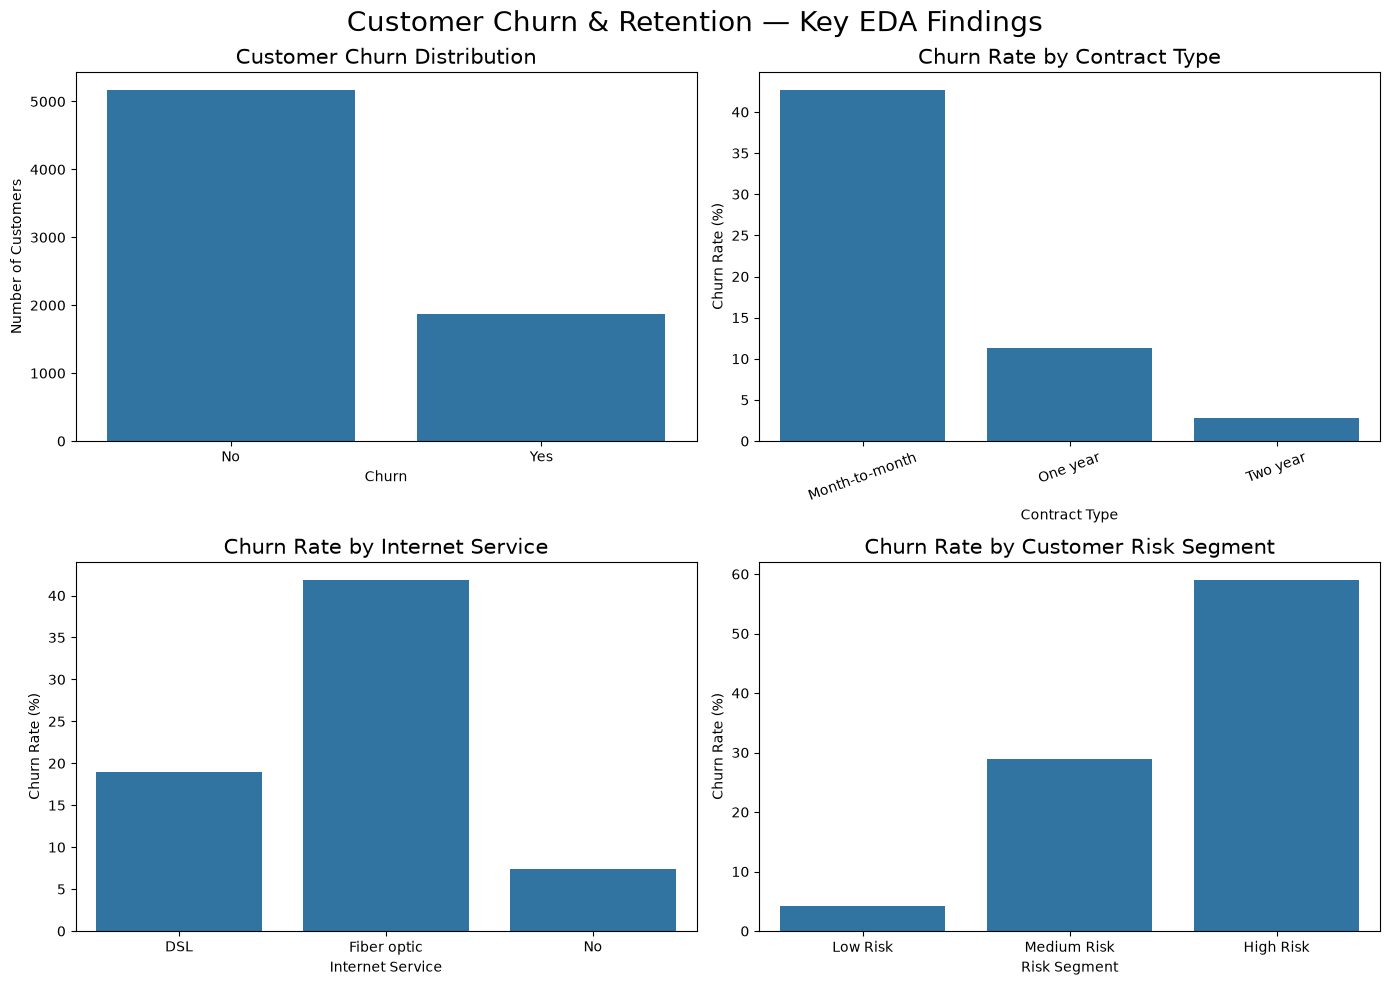

In [48]:
# STEP 57 — Key EDA Visualizations

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. Churn Distribution
sns.countplot(data=df, x="Churn", ax=axes[0, 0])
axes[0, 0].set_title("Customer Churn Distribution", fontsize=15)
axes[0, 0].set_xlabel("Churn")
axes[0, 0].set_ylabel("Number of Customers")

# 2. Churn by Contract
sns.barplot(
    x=contract_churn_rate.index,
    y=contract_churn_rate["Yes"],
    ax=axes[0, 1]
)
axes[0, 1].set_title("Churn Rate by Contract Type", fontsize=15)
axes[0, 1].set_xlabel("Contract Type")
axes[0, 1].set_ylabel("Churn Rate (%)")
axes[0, 1].tick_params(axis="x", rotation=20)

# 3. Churn by Internet Service
sns.barplot(
    x=internet_churn_rate.index,
    y=internet_churn_rate["Yes"],
    ax=axes[1, 0]
)
axes[1, 0].set_title("Churn Rate by Internet Service", fontsize=15)
axes[1, 0].set_xlabel("Internet Service")
axes[1, 0].set_ylabel("Churn Rate (%)")

# 4. Churn by Risk Segment
risk_values = risk_churn_rate["Yes"].reindex(
    ["Low Risk", "Medium Risk", "High Risk"]
)

sns.barplot(
    x=risk_values.index,
    y=risk_values.values,
    ax=axes[1, 1]
)
axes[1, 1].set_title("Churn Rate by Customer Risk Segment", fontsize=15)
axes[1, 1].set_xlabel("Risk Segment")
axes[1, 1].set_ylabel("Churn Rate (%)")

plt.suptitle(
    "Customer Churn & Retention — Key EDA Findings",
    fontsize=20
)

plt.tight_layout()
plt.show()

In [49]:
# Save the key EDA visualization

output_image = "../Screenshots/EDA_Key_Findings.png"

fig.savefig(
    output_image,
    dpi=300,
    bbox_inches="tight"
)

print("EDA visualization saved successfully!")
print("File:", output_image)

EDA visualization saved successfully!
File: ../Screenshots/EDA_Key_Findings.png
